In [12]:
from google.colab import drive
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import DataLoader, random_split
import numpy as np
import librosa
import soundfile as sf
import os, zipfile, time
import matplotlib.pyplot as plt
from IPython.display import Audio

drive.mount('/content/drive')
print('GPU available:', torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available: True


In [2]:
!pip install -q librosa soundfile pesq pystoi

  Preparing metadata (setup.py) ... done


In [13]:
ZIP_PATH="/content/drive/MyDrive/voice_agent/generated.zip"
EXTRACT_DIR = '/content/data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

if not os.path.exists('/content/data/data/generated'):
    print('Extracting data...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

NOISY_WAV = '/content/data/data/generated/noisy'
CLEAN_WAV = '/content/data/data/generated/clean'
SPEC_NOISY = '/content/data/spectrograms/noisy'
SPEC_CLEAN = '/content/data/spectrograms/clean'
PHASE_DIR  = '/content/data/phases'

for d in [SPEC_NOISY, SPEC_CLEAN, PHASE_DIR]:
    os.makedirs(d, exist_ok=True)
print('Directories ready.')

Directories ready.


In [4]:
import numpy as np
import librosa

SR = 16000
N_FFT = 512
HOP_LEN = 128

def to_spectrogram(wav):
    stft = librosa.stft(wav, n_fft=N_FFT, hop_length=HOP_LEN)
    return np.abs(stft).astype(np.float32), np.angle(stft).astype(np.float32)

def normalize(mag):
    log_mag = np.log1p(mag)
    mn, mx = log_mag.min(), log_mag.max()
    if mx - mn < 1e-8: return np.zeros_like(log_mag)
    return ((log_mag - mn) / (mx - mn)).astype(np.float32)

def process_data():
    for subset, src, dest in [('noisy', NOISY_WAV, SPEC_NOISY), ('clean', CLEAN_WAV, SPEC_CLEAN)]:
        files = sorted([f for f in os.listdir(src) if f.endswith('.wav')])
        print(f'Processing {subset} ({len(files)} files)...')
        for f in files:
            wav, _ = librosa.load(os.path.join(src, f), sr=SR)
            mag, phase = to_spectrogram(wav)
            norm_mag = normalize(mag)
            np.save(os.path.join(dest, f.replace('.wav', '.npy')), norm_mag)
            if subset == 'noisy':
                np.save(os.path.join(PHASE_DIR, f.replace('.wav', '.npy')), phase)
    print('Preprocessing complete.')

process_data()

Processing noisy (6000 files)...
Processing clean (6000 files)...
Preprocessing complete.


In [14]:
class CDAE(nn.Module):
    def __init__(self):
        super(CDAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        target_size = x.size()[2:]
        x = self.encoder(x)
        x = self.decoder(x)
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
        return x

class SpectrogramDataset(data.Dataset):
    def __init__(self, noisy_dir, clean_dir):
        self.filenames = sorted([f for f in os.listdir(noisy_dir) if f.endswith('.npy')])
        self.noisy_dir = noisy_dir
        self.clean_dir = clean_dir

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        noisy = np.load(os.path.join(self.noisy_dir, name))
        clean = np.load(os.path.join(self.clean_dir, name))
        return torch.FloatTensor(noisy).unsqueeze(0), torch.FloatTensor(clean).unsqueeze(0)

In [8]:
from torch.utils.data import DataLoader, random_split
import time

MODEL_OUT = '/content/drive/MyDrive/voice_agent/model.pth'
EPOCHS = 50
LR = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize Dataset and Loaders
full_ds = SpectrogramDataset(SPEC_NOISY, SPEC_CLEAN)
train_size = int(0.9 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)

# Re-initialize Model with the fix, Loss, and Optimizer
model = CDAE().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val = float('inf')
train_losses, val_losses = [], []

print(f'Training on: {device}')
print(f'\n{"Epoch":>6}  {"Train":>10}  {"Val":>10}  {"LR":>8}  {"Time":>7}  Status')
print("-" * 58)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tl = 0
    for n, c in train_loader:
        n, c = n.to(device), c.to(device)
        optimizer.zero_grad()
        output = model(n)
        loss = criterion(output, c)
        loss.backward()
        optimizer.step()
        tl += loss.item() * n.size(0)
    tl /= len(train_ds)

    model.eval()
    vl = 0
    with torch.no_grad():
        for n, c in val_loader:
            n, c = n.to(device), c.to(device)
            vl += criterion(model(n), c).item() * n.size(0)
    vl /= len(val_ds)

    train_losses.append(tl); val_losses.append(vl)
    scheduler.step(vl)
    lr = optimizer.param_groups[0]['lr']
    status = ''
    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), MODEL_OUT)
        status = 'SAVED'
    print(f'{epoch:>6}  {tl:>10.6f}  {vl:>10.6f}  {lr:>8.2e}  {time.time()-t0:>6.1f}s  {status}')

Training on: cuda

 Epoch       Train         Val        LR     Time  Status
----------------------------------------------------------
     1    0.024386    0.004644  1.00e-03    41.9s  SAVED
     2    0.004255    0.003805  1.00e-03    32.4s  SAVED
     3    0.003468    0.003319  1.00e-03    20.6s  SAVED
     4    0.003070    0.002890  1.00e-03    20.3s  SAVED
     5    0.002930    0.002847  1.00e-03    20.8s  SAVED
     6    0.002826    0.002722  1.00e-03    20.2s  SAVED
     7    0.002773    0.002664  1.00e-03    20.5s  SAVED
     8    0.002712    0.002603  1.00e-03    20.4s  SAVED
     9    0.002684    0.002556  1.00e-03    20.7s  SAVED
    10    0.002624    0.002558  1.00e-03    20.3s  
    11    0.002600    0.002552  1.00e-03    21.3s  SAVED
    12    0.002540    0.002455  1.00e-03    21.0s  SAVED
    13    0.002528    0.002438  1.00e-03    21.5s  SAVED
    14    0.002499    0.002412  1.00e-03    21.3s  SAVED
    15    0.002479    0.002380  1.00e-03    21.7s  SAVED
    16    0.00

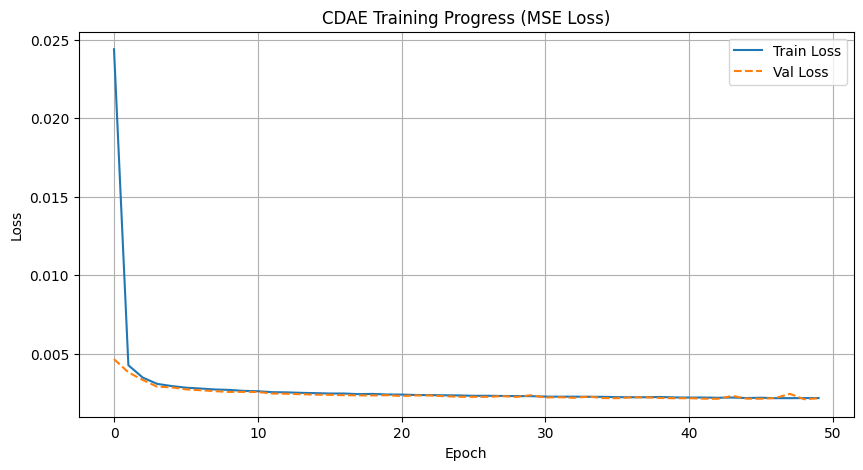

Final Model saved at: /content/drive/MyDrive/voice_agent/model.pth
Best Validation Loss: 0.002091


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss', linestyle='--')
plt.title('CDAE Training Progress (MSE Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f'Final Model saved at: {MODEL_OUT}')
print(f'Best Validation Loss: {min(val_losses):.6f}')

### 6. Inference: Generate Denoised Output
This cell loads the best saved model and applies it to a sample from the noisy dataset to generate a denoised `.wav` file.

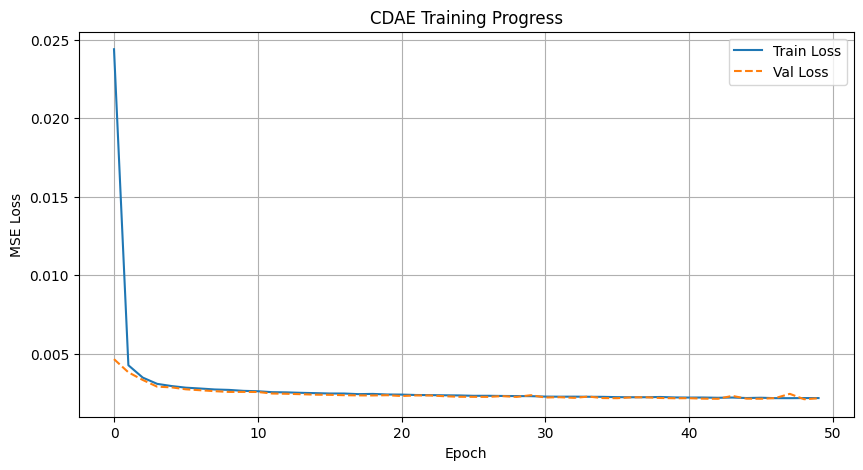

Final Model saved at: /content/drive/MyDrive/voice_agent/model.pth


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss', linestyle='--')
plt.title('CDAE Training Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f'Final Model saved at: {MODEL_OUT}')

In [15]:
# --- INFERENCE AND OUTPUT GENERATION ---
MODEL_PATH = '/content/drive/MyDrive/voice_agent/model.pth'
model = CDAE().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# Select sample
sample_name = sorted(os.listdir(SPEC_NOISY))[0]
noisy_spec = np.load(os.path.join(SPEC_NOISY, sample_name))
phase = np.load(os.path.join(PHASE_DIR, sample_name))

# Denoise
with torch.no_grad():
    input_tensor = torch.FloatTensor(noisy_spec).unsqueeze(0).unsqueeze(0).to(device)
    output_spec = model(input_tensor).squeeze().cpu().numpy()

# Reconstruct
denoised_mag = np.expm1(output_spec)
stft_recon = denoised_mag * (np.cos(phase) + 1j * np.sin(phase))
audio_out = librosa.istft(stft_recon, hop_length=128)

# Save and Play
sf.write('/content/denoised_output.wav', audio_out, 16000)
print('Denoised output generated: /content/denoised_output.wav')
display(Audio('/content/denoised_output.wav', rate=16000))

Denoised output generated: /content/denoised_output.wav


### 7. Batch Inference: 5 Additional Samples
Generating and displaying more examples of the model's denoising performance.

In [17]:
import os
import numpy as np
import torch
import soundfile as sf
import librosa
from IPython.display import Audio, display

# Get a list of 5 more samples
additional_samples = sorted(os.listdir(SPEC_NOISY))[1:6]

model.eval()
for i, sample_name in enumerate(additional_samples):
    # 1. Load data
    noisy_spec = np.load(os.path.join(SPEC_NOISY, sample_name))
    phase = np.load(os.path.join(PHASE_DIR, sample_name))

    # 2. Reconstruct original 'Before' audio
    # Use the same inverse logic (expm1) assuming data was log-normalized
    # Note: Using original noisy mag before model for the 'Before' sample
    noisy_mag = np.expm1(noisy_spec)
    stft_noisy = noisy_mag * (np.cos(phase) + 1j * np.sin(phase))
    audio_before = librosa.istft(stft_noisy, hop_length=128)

    # 3. Denoise with Model
    with torch.no_grad():
        input_tensor = torch.FloatTensor(noisy_spec).unsqueeze(0).unsqueeze(0).to(device)
        output_spec = model(input_tensor).squeeze().cpu().numpy()

    # 4. Reconstruct 'After' audio
    denoised_mag = np.expm1(output_spec)
    stft_after = denoised_mag * (np.cos(phase) + 1j * np.sin(phase))
    audio_after = librosa.istft(stft_after, hop_length=128)

    # 5. Save and Display
    before_path = f'/content/sound_{i+1}_before.wav'
    after_path = f'/content/sound_{i+1}_after.wav'

    sf.write(before_path, audio_before, 16000)
    sf.write(after_path, audio_after, 16000)

    print(f'--- Sample {i+1} ({sample_name}) ---')
    print('Before:')
    display(Audio(before_path, rate=16000))
    print('After:')
    display(Audio(after_path, rate=16000))
    print('\n')

--- Sample 1 (1272-128104-0001_cockpit_0dB.npy) ---
Before:


After:




--- Sample 2 (1272-128104-0001_cockpit_10dB.npy) ---
Before:


After:




--- Sample 3 (1272-128104-0001_cockpit_5dB.npy) ---
Before:


After:




--- Sample 4 (1272-128104-0001_engine_-5dB.npy) ---
Before:


After:




--- Sample 5 (1272-128104-0001_engine_0dB.npy) ---
Before:


After:


In [18]:
!pip install -q Flask flask-cors pydub

### 8. Flask API with CORS
This server provides a `/denoise` endpoint. It handles:
1.  **Format Conversion**: Uses `pydub` to convert any input format to 16kHz mono WAV.
2.  **Preprocessing**: Performs STFT and normalization.
3.  **Inference**: Runs the CDAE model.
4.  **Post-processing**: Reconstructs audio and returns it as a file response.

In [19]:
import os
import torch
import numpy as np
import librosa
import soundfile as sf
from flask import Flask, request, send_file
from flask_cors import CORS
from pydub import AudioSegment
import io

app = Flask(__name__)
CORS(app)

# Load the global model
MODEL_PATH = '/content/drive/MyDrive/voice_agent/model.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CDAE().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# Constants for preprocessing
SR = 16000
N_FFT = 512
HOP_LEN = 128

def preprocess_audio(audio_bytes):
    # 1. Load any format via pydub and normalize to 16k mono
    audio = AudioSegment.from_file(io.BytesIO(audio_bytes))
    audio = audio.set_frame_rate(SR).set_channels(1)

    # 2. Convert to numpy array
    samples = np.array(audio.get_array_of_samples()).astype(np.float32) / 32768.0

    # 3. STFT
    stft = librosa.stft(samples, n_fft=N_FFT, hop_length=HOP_LEN)
    mag = np.abs(stft)
    phase = np.angle(stft)

    # 4. Normalize magnitude (log1p + min-max scaling as used in training)
    log_mag = np.log1p(mag)
    mn, mx = log_mag.min(), log_mag.max()
    if mx - mn < 1e-8:
        norm_mag = np.zeros_like(log_mag)
    else:
        norm_mag = (log_mag - mn) / (mx - mn)

    return torch.FloatTensor(norm_mag).unsqueeze(0).unsqueeze(0).to(device), phase

@app.route('/denoise', methods=['POST'])
def denoise_endpoint():
    if 'file' not in request.files:
        return {"error": "No file provided"}, 400

    file = request.files['file']
    input_bytes = file.read()

    try:
        # Preprocess and Inference
        input_tensor, phase = preprocess_audio(input_bytes)
        with torch.no_grad():
            output_spec = model(input_tensor).squeeze().cpu().numpy()

        # Reconstruction
        denoised_mag = np.expm1(output_spec)
        stft_recon = denoised_mag * (np.cos(phase) + 1j * np.sin(phase))
        audio_out = librosa.istft(stft_recon, hop_length=HOP_LEN)

        # Export to WAV buffer
        buffer = io.BytesIO()
        sf.write(buffer, audio_out, SR, format='WAV')
        buffer.seek(0)

        return send_file(buffer, mimetype='audio/wav', as_attachment=True, download_name='denoised.wav')

    except Exception as e:
        return {"error": str(e)}, 500

print("Flask server ready. To run this in Colab, you typically need a tunnel like localtunnel or ngrok.")
# app.run(port=5000) # Uncomment to run locally

Flask server ready. To run this in Colab, you typically need a tunnel like localtunnel or ngrok.


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


### 9. Docker Deployment Guide

To run this API as a Docker container, you need to follow these steps on your local machine:

1.  **Prepare the folder**: Create a directory and place your `model.pth`, `app.py` (the Flask code), and the files generated below inside it.
2.  **Install Docker**: Ensure Docker Desktop is running.
3.  **Build and Run**: Use the terminal commands provided at the bottom of this section.

In [ ]:
# 1. Create requirements.txt
requirements = """flask
flask-cors
torch
torchvision
torchaudio
numpy
librosa
soundfile
pydub
gunicorn
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)

# 2. Create Dockerfile
dockerfile = """FROM python:3.10-slim

# Install system dependencies for audio processing
RUN apt-get update && apt-get install -y ffmpeg libsndfile1 && rm -rf /var/lib/apt/lists/*

WORKDIR /app

# Copy requirements and install
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy your application code and model
# Ensure model.pth is in the same directory when building
COPY . .

# Expose the port Flask runs on
EXPOSE 5000

# Run with Gunicorn for production-grade serving
CMD ["gunicorn", "--bind", "0.0.0.0:5000", "app:app"]
"""
with open('Dockerfile', 'w') as f:
    f.write(dockerfile)

print("Dockerfile and requirements.txt have been created in /content/")

#### Commands to run locally:

After downloading the files to your computer, open a terminal in that folder and run:

```bash
# 1. Build the image (tag it as 'voice-denoiser')
docker build -t voice-denoiser .

# 2. Run the container
# -p 5000:5000 maps your computer's port 5000 to the container
docker run -p 5000:5000 voice-denoiser
```

**Note on File Storage**: Inside a Docker container, storage is ephemeral (wiped when deleted). If you want to save processed files permanently on your host machine, use a **Volume**:
```bash
docker run -p 5000:5000 -v /path/on/your/pc:/app/storage voice-denoiser
```